# Proyecto Final Entrega Parcial
## Machine Learning

**Datasets:**
- Regresión: California Housing Prices
- Clasificación: Adult Census Income

---

## 0. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, confusion_matrix

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'axes.titlesize': 12})

---
# PARTE I Regresión: California Housing Prices

## 1. Introducción y Definición del Problema

**Dataset:** California Housing Prices (U.S. Census Bureau, 1990)  
**Fuente:** https://www.kaggle.com/datasets/camnugent/california-housing-prices

**Problema:** Predecir el valor mediano de viviendas (`median_house_value`) en distritos censales de California a partir de variables socioeconómicas y geográficas. La variable objetivo es continua (USD), definiendo una tarea de **regresión supervisada**.

**¿Por qué importa?** El precio de la vivienda es un indicador clave de mercado inmobiliario; modelos precisos permiten a compradores, vendedores e instituciones tomar mejores decisiones de inversión y política pública.

**Métricas elegidas:**
- **RMSE**: penaliza errores grandes, apropiado dado el amplio rango [$15K–$500K].
- **R²**: mide proporción de varianza explicada; permite comparar modelos independientemente de la escala.

## 2. Carga de Datos

In [2]:
housing_df = pd.read_csv('data/housing.csv')
print(f'Dimensiones: {housing_df.shape}')
print(f'Tipos:\n{housing_df.dtypes}')
housing_df.head()

Dimensiones: (20640, 10)
Tipos:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 2. EDA California Housing

### 2.1 Estadísticas Descriptivas

In [3]:
display(housing_df.describe().round(2))
print(f'\nValores nulos:\n{housing_df.isnull().sum()}')
print(f'\nocean_proximity:\n{housing_df["ocean_proximity"].value_counts()}')

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00



Valores nulos:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

ocean_proximity:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


### 2.2 Distribución de la Variable Objetivo

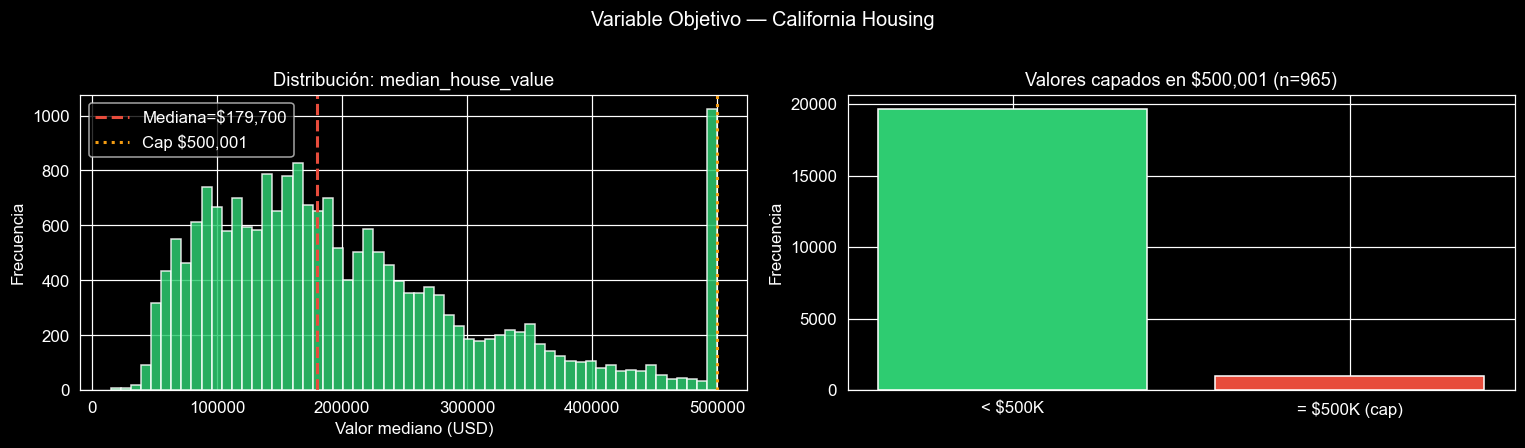

Filas con cap: 965 (4.7%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(housing_df['median_house_value'], bins=60, color='#2ecc71', edgecolor='white', alpha=0.85)
axes[0].axvline(housing_df['median_house_value'].median(), color='#e74c3c', lw=2,
                linestyle='--', label=f'Mediana=${housing_df["median_house_value"].median():,.0f}')
axes[0].axvline(500001, color='#f39c12', lw=2, linestyle=':', label='Cap $500,001')
axes[0].set_title('Distribución: median_house_value')
axes[0].set_xlabel('Valor mediano (USD)'); axes[0].set_ylabel('Frecuencia'); axes[0].legend()

cap_count = (housing_df['median_house_value'] >= 500001).sum()
axes[1].bar(['< $500K', '= $500K (cap)'],
            [len(housing_df) - cap_count, cap_count],
            color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[1].set_title(f'Valores capados en $500,001 (n={cap_count})')
axes[1].set_ylabel('Frecuencia')
plt.suptitle('Variable Objetivo — California Housing', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()
print(f'Filas con cap: {cap_count} ({cap_count/len(housing_df)*100:.1f}%)')

### 2.3 Distribuciones de Features Numéricas

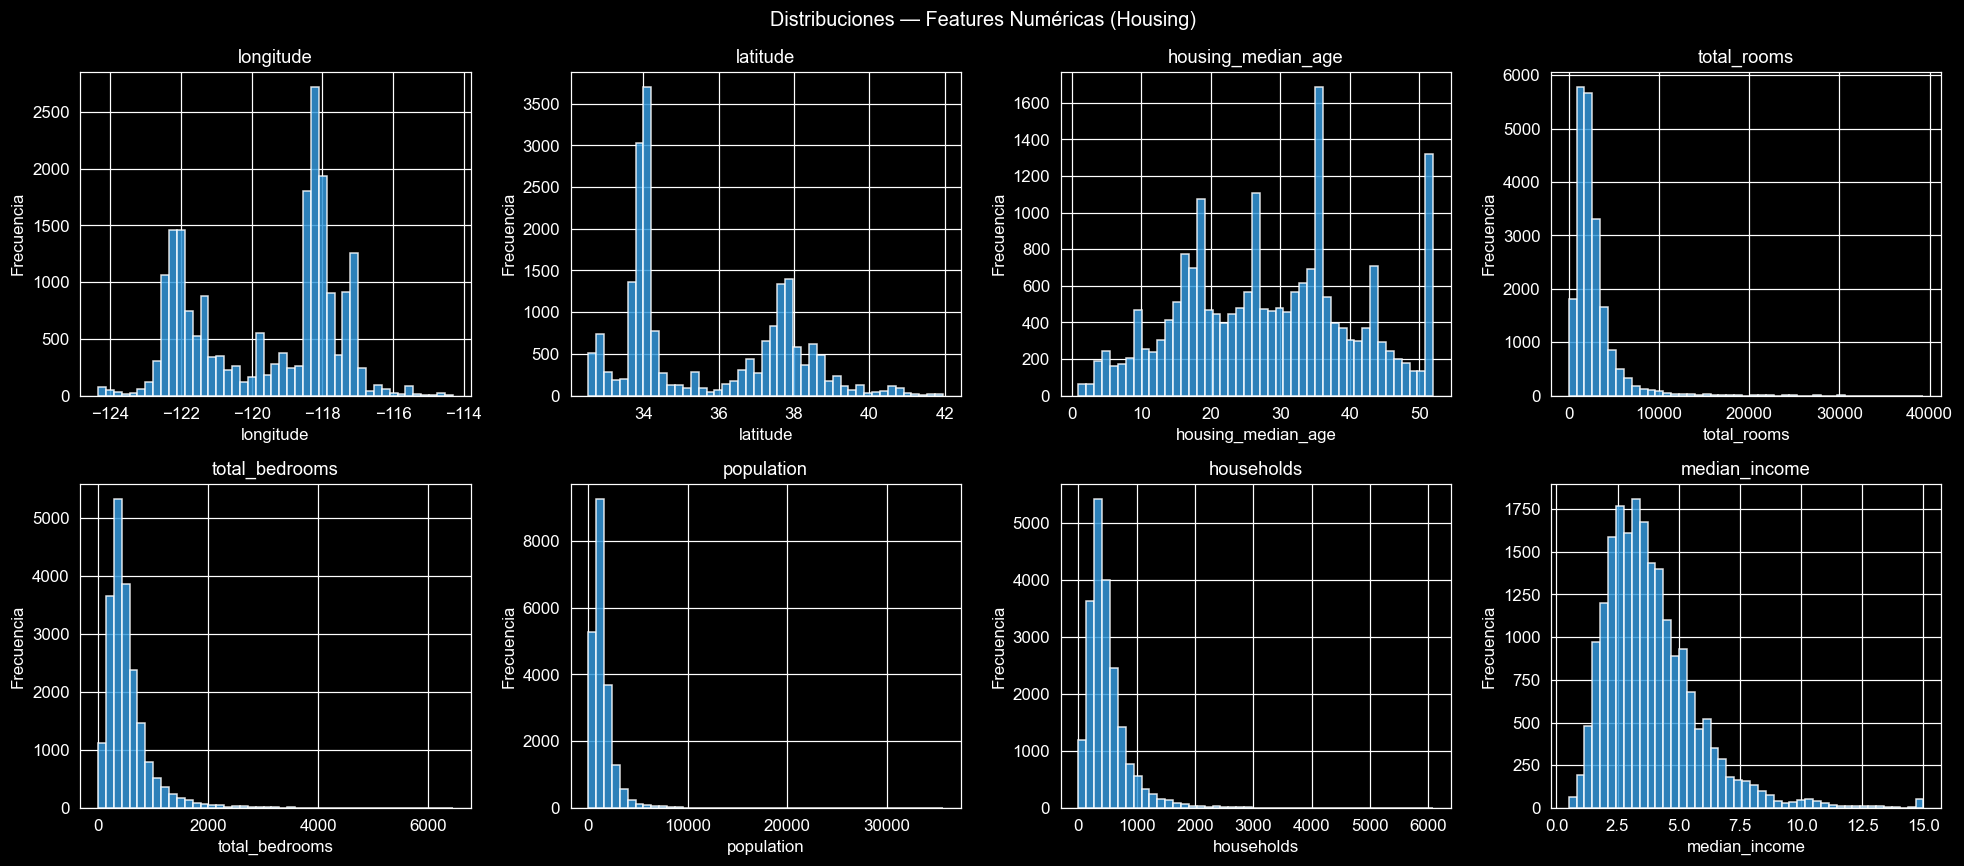

In [5]:
num_cols_h = ['longitude', 'latitude', 'housing_median_age',
              'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols_h):
    axes[i].hist(housing_df[col].dropna(), bins=45, color='#3498db', edgecolor='white', alpha=0.85)
    axes[i].set_title(col); axes[i].set_xlabel(col); axes[i].set_ylabel('Frecuencia')
plt.suptitle('Distribuciones — Features Numéricas (Housing)', fontsize=13)
plt.tight_layout(); plt.show()

### 2.4 Mapa Geográfico de Precios

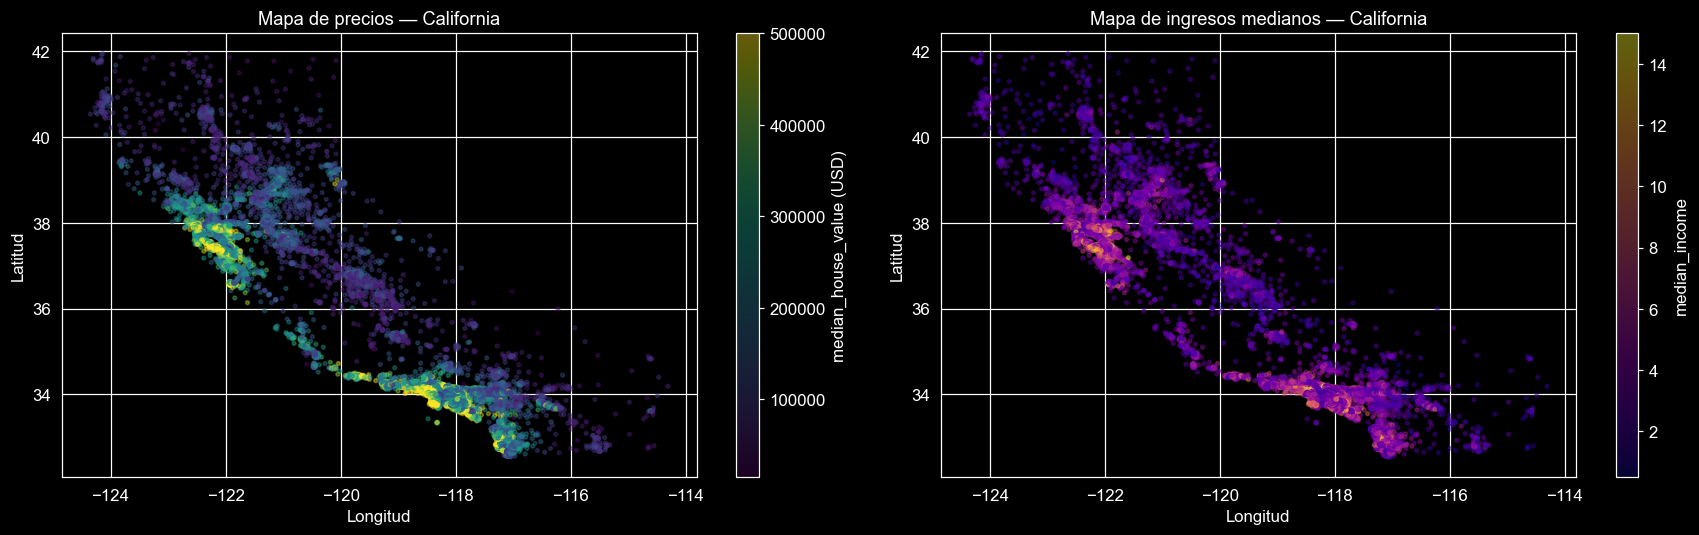

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sc = axes[0].scatter(housing_df['longitude'], housing_df['latitude'],
                     c=housing_df['median_house_value'], cmap='viridis', alpha=0.4, s=6)
plt.colorbar(sc, ax=axes[0], label='median_house_value (USD)')
axes[0].set_xlabel('Longitud'); axes[0].set_ylabel('Latitud')
axes[0].set_title('Mapa de precios — California')

sc2 = axes[1].scatter(housing_df['longitude'], housing_df['latitude'],
                      c=housing_df['median_income'], cmap='plasma', alpha=0.4, s=6)
plt.colorbar(sc2, ax=axes[1], label='median_income')
axes[1].set_xlabel('Longitud'); axes[1].set_ylabel('Latitud')
axes[1].set_title('Mapa de ingresos medianos — California')
plt.tight_layout(); plt.show()

### 2.5 Mapa de Correlaciones

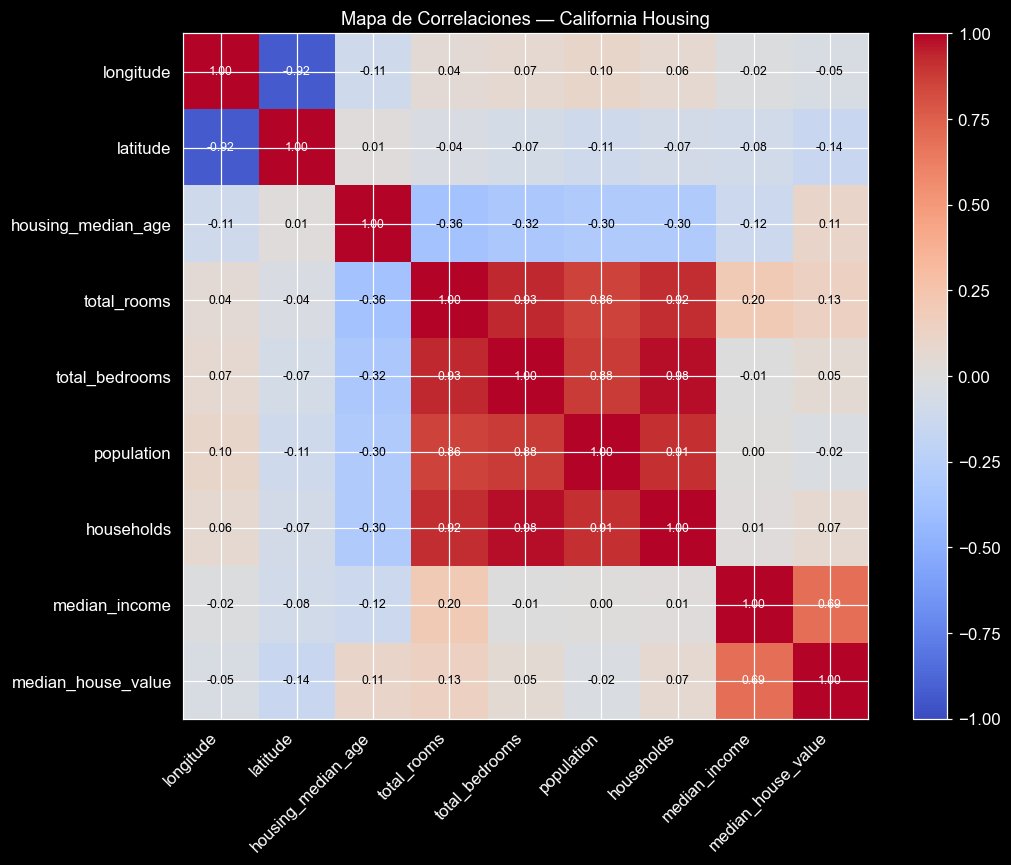

Correlación con median_house_value:
median_house_value    1.000
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.050
population           -0.025
longitude            -0.046
latitude             -0.144
Name: median_house_value, dtype: float64


In [7]:
housing_num = housing_df[num_cols_h + ['median_house_value']].copy()
corr_h = housing_num.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_h, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_h))); ax.set_xticklabels(corr_h.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr_h))); ax.set_yticklabels(corr_h.columns)
for i in range(len(corr_h)):
    for j in range(len(corr_h)):
        ax.text(j, i, f'{corr_h.iloc[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='white' if abs(corr_h.iloc[i,j]) > 0.5 else 'black')
plt.colorbar(im, ax=ax)
ax.set_title('Mapa de Correlaciones — California Housing')
plt.tight_layout(); plt.show()

print('Correlación con median_house_value:')
print(corr_h['median_house_value'].sort_values(ascending=False).round(3))

### 2.6 Outliers

Análisis de outliers (IQR):
  total_rooms            outliers: 1287 (6.2%)
  total_bedrooms         outliers: 1271 (6.2%)
  population             outliers: 1196 (5.8%)
  households             outliers: 1220 (5.9%)
  median_income          outliers:  681 (3.3%)


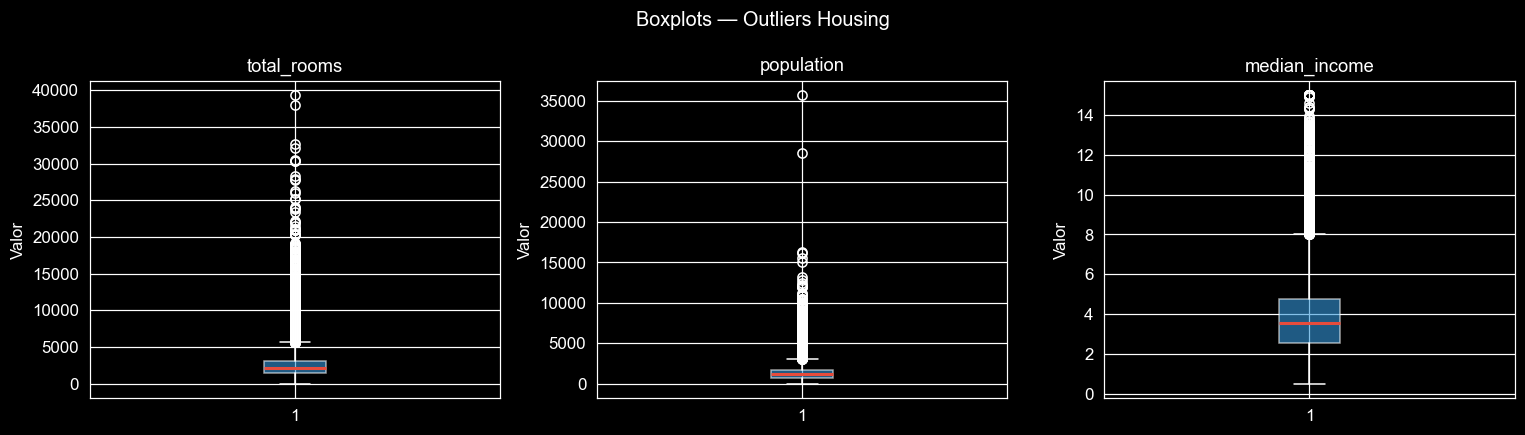

In [8]:
print('Análisis de outliers (IQR):')
for col in ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']:
    q25, q75 = housing_df[col].quantile([0.25, 0.75])
    iqr = q75 - q25
    n = ((housing_df[col] < q25 - 1.5*iqr) | (housing_df[col] > q75 + 1.5*iqr)).sum()
    print(f'  {col:<22} outliers: {n:>4} ({n/len(housing_df)*100:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['total_rooms', 'population', 'median_income']):
    ax.boxplot(housing_df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6),
               medianprops=dict(color='#e74c3c', linewidth=2))
    ax.set_title(col); ax.set_ylabel('Valor')
plt.suptitle('Boxplots — Outliers Housing', fontsize=13)
plt.tight_layout(); plt.show()

## 3. Preprocesamiento California Housing

| Decisión | Justificación |
|---|---|
| Eliminar filas con `median_house_value = 500001` | Cap artificial que distorsiona la distribución del target |
| Imputar `total_bedrooms` con mediana | 207 nulos (1%); mediana es robusta a outliers |
| One-Hot Encoding de `ocean_proximity` | Variable nominal sin orden natural |
| Estandarización con `StandardScaler` | Features en escalas muy distintas; requerido por GD |
| División 60/20/20 (train/val/test) | Validación para monitorear convergencia; test para evaluación final |

In [9]:
df_h = housing_df.copy()

# 1. Eliminar cap artificial
df_h = df_h[df_h['median_house_value'] < 500001].reset_index(drop=True)
print(f'Filas tras eliminar cap: {len(df_h)}')

# 2. Imputar total_bedrooms con mediana
median_tb = df_h['total_bedrooms'].median()
df_h['total_bedrooms'] = df_h['total_bedrooms'].fillna(median_tb)
print(f'Nulos restantes: {df_h.isnull().sum().sum()}')

# 3. One-Hot Encoding
df_h = pd.get_dummies(df_h, columns=['ocean_proximity'], drop_first=True)
print(f'Columnas post-OHE: {df_h.shape[1]}')

# 4. Separar X e y
y_h = df_h['median_house_value'].values.reshape(-1, 1)
X_h = df_h.drop(columns=['median_house_value']).values.astype(float)
feature_names_h = df_h.drop(columns=['median_house_value']).columns.tolist()

# 5. División 60/20/20
X_h_tmp, X_h_test, y_h_tmp, y_h_test = train_test_split(X_h, y_h, test_size=0.20, random_state=42)
X_h_train, X_h_val, y_h_train, y_h_val = train_test_split(X_h_tmp, y_h_tmp, test_size=0.25, random_state=42)

# 6. Estandarización — fit SOLO en train
scaler_hX = StandardScaler(); scaler_hy = StandardScaler()
X_h_train_s = scaler_hX.fit_transform(X_h_train)
X_h_val_s   = scaler_hX.transform(X_h_val)
X_h_test_s  = scaler_hX.transform(X_h_test)
y_h_train_s = scaler_hy.fit_transform(y_h_train)
y_h_val_s   = scaler_hy.transform(y_h_val)
y_h_test_s  = scaler_hy.transform(y_h_test)

print(f'Train: {X_h_train_s.shape} | Val: {X_h_val_s.shape} | Test: {X_h_test_s.shape}')

Filas tras eliminar cap: 19675
Nulos restantes: 0
Columnas post-OHE: 13
Train: (11805, 12) | Val: (3935, 12) | Test: (3935, 12)


## 4. Implementación Regresión Lineal con Gradient Descent (NumPy)

**Predicción:** $\hat{y} = X\mathbf{w} + b$

**MSE Loss:** $J(\mathbf{w}) = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2$

**Gradientes:** $\nabla_w J = \frac{2}{n} X^\top (\hat{y} - y), \quad \nabla_b J = \frac{2}{n}\overline{(\hat{y}-y)}$

**Actualización SGD:** $\mathbf{w} \leftarrow \mathbf{w} - \alpha \nabla_w J$

In [10]:
class LinearRegressionGD:
    """
    Regresión Lineal con Gradient Descent implementada usando la linreria NumPy.
    Tasa con aprendizaje y epocas configurables.
    """

    def __init__(self, lr=0.01, epochs=1000, seed=42):
        self.lr     = lr
        self.epochs = epochs
        self.seed   = seed
        self.w = self.b = None
        self.train_loss_history = []
        self.val_loss_history   = []

    def _mse(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def _forward(self, X):
        return X @ self.w + self.b

    def _gradients(self, X, y, y_pred):
        n     = X.shape[0]
        error = y_pred - y
        return (2/n) * X.T @ error, (2/n) * error.mean(axis=0)

    def fit(self, X_train, y_train, X_val=None, y_val=None, val_freq=50):
        np.random.seed(self.seed)
        self.w = np.zeros((X_train.shape[1], 1))
        self.b = np.zeros(1)

        for epoch in range(self.epochs):
            y_pred = self._forward(X_train)
            loss   = self._mse(y_train, y_pred)
            self.train_loss_history.append(loss)

            gw, gb = self._gradients(X_train, y_train, y_pred)
            self.w -= self.lr * gw
            self.b -= self.lr * gb

            if X_val is not None and epoch % val_freq == 0:
                val_loss = self._mse(y_val, self._forward(X_val))
                self.val_loss_history.append(val_loss)
                if epoch % 200 == 0:
                    print(f'Epoch {epoch:<5} | Train MSE: {loss:.4f} | Val MSE: {val_loss:.4f}')
        return self

    def predict(self, X):
        return self._forward(X)

In [11]:
model_lr = LinearRegressionGD(lr=0.05, epochs=1000, seed=42)
model_lr.fit(X_h_train_s, y_h_train_s, X_h_val_s, y_h_val_s, val_freq=50)

Epoch 0     | Train MSE: 1.0000 | Val MSE: 0.8909
Epoch 200   | Train MSE: 0.3941 | Val MSE: 0.4034
Epoch 400   | Train MSE: 0.3908 | Val MSE: 0.3983
Epoch 600   | Train MSE: 0.3900 | Val MSE: 0.3968
Epoch 800   | Train MSE: 0.3898 | Val MSE: 0.3962


### 4.1 Curva de Pérdida Regresión Lineal

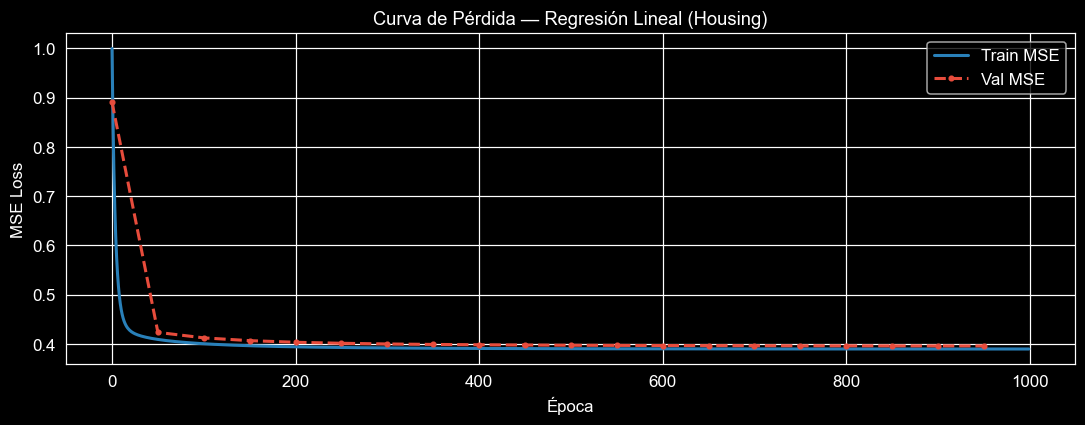

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(model_lr.train_loss_history, label='Train MSE', color='#2980b9', lw=2)
ax.plot(np.arange(0, model_lr.epochs, 50), model_lr.val_loss_history,
        label='Val MSE', color='#e74c3c', lw=2, linestyle='--', marker='o', markersize=3)
ax.set_xlabel('Época'); ax.set_ylabel('MSE Loss')
ax.set_title('Curva de Pérdida — Regresión Lineal (Housing)')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Evaluación California Housing

EVALUACIÓN — Regresión Lineal (Housing)
Métrica                     Train         Test
----------------------------------------------
RMSE (USD)                 60,364       62,509
R²                         0.6103       0.6081


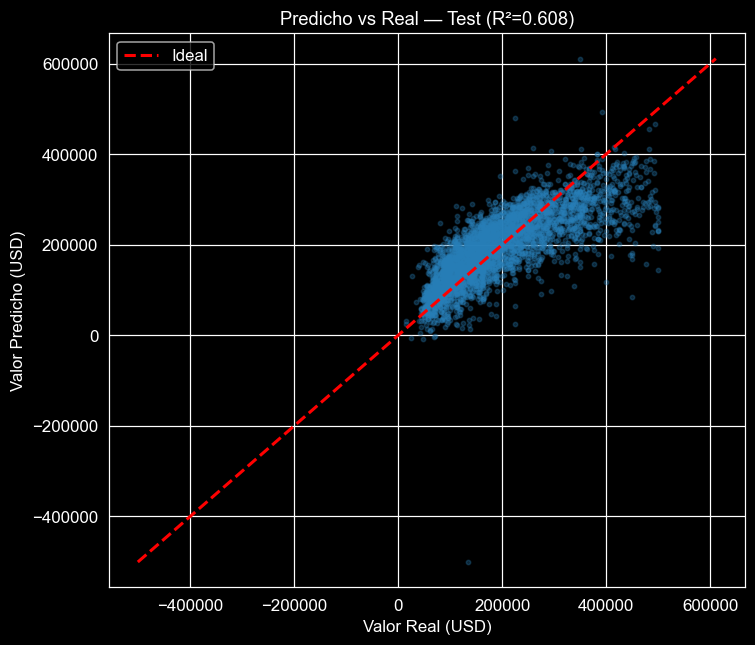

In [13]:
y_pred_tr_s = model_lr.predict(X_h_train_s)
y_pred_te_s = model_lr.predict(X_h_test_s)

y_pred_train_h = scaler_hy.inverse_transform(y_pred_tr_s)
y_pred_test_h  = scaler_hy.inverse_transform(y_pred_te_s)
y_train_orig   = scaler_hy.inverse_transform(y_h_train_s)
y_test_orig    = scaler_hy.inverse_transform(y_h_test_s)

rmse_tr = np.sqrt(mean_squared_error(y_train_orig, y_pred_train_h))
rmse_te = np.sqrt(mean_squared_error(y_test_orig,  y_pred_test_h))
r2_tr   = r2_score(y_train_orig, y_pred_train_h)
r2_te   = r2_score(y_test_orig,  y_pred_test_h)

print('=' * 50)
print('EVALUACIÓN — Regresión Lineal (Housing)')
print('=' * 50)
print(f"{'Métrica':<20} {'Train':>12} {'Test':>12}")
print('-' * 46)
print(f"{'RMSE (USD)':<20} {rmse_tr:>12,.0f} {rmse_te:>12,.0f}")
print(f"{'R²':<20} {r2_tr:>12.4f} {r2_te:>12.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test_orig, y_pred_test_h, alpha=0.3, s=8, color='#2980b9')
lims = [min(y_test_orig.min(), y_pred_test_h.min()),
        max(y_test_orig.max(), y_pred_test_h.max())]
ax.plot(lims, lims, 'r--', lw=2, label='Ideal')
ax.set_xlabel('Valor Real (USD)'); ax.set_ylabel('Valor Predicho (USD)')
ax.set_title(f'Predicho vs Real — Test (R²={r2_te:.3f})')
ax.legend(); plt.tight_layout(); plt.show()

### 5.1 Interpretación de Coeficientes Housing

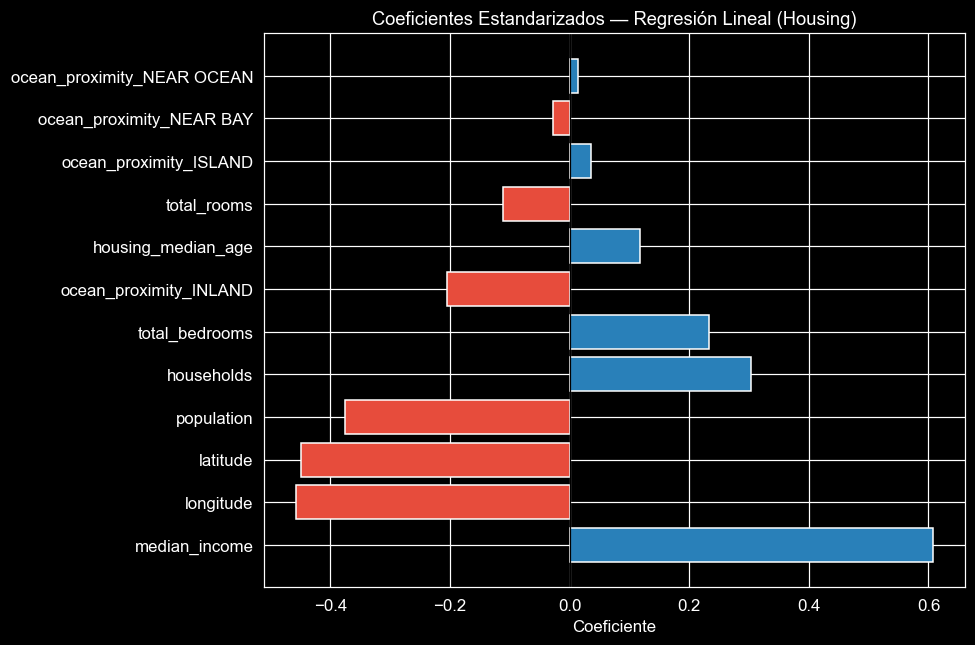

,feature,coeficiente
7,median_income,0.607298
0,longitude,-0.456902
1,latitude,-0.448444
5,population,-0.374526
6,households,0.303545
4,total_bedrooms,0.233655
8,ocean_proximity_INLAND,-0.205220
2,housing_median_age,0.117489
3,total_rooms,-0.111602
9,ocean_proximity_ISLAND,0.035782


In [14]:
coef_df_h = pd.DataFrame({'feature': feature_names_h,
                           'coeficiente': model_lr.w.flatten()})\
             .sort_values('coeficiente', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colores = ['#e74c3c' if c < 0 else '#2980b9' for c in coef_df_h['coeficiente']]
ax.barh(coef_df_h['feature'], coef_df_h['coeficiente'], color=colores, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Coeficientes Estandarizados — Regresión Lineal (Housing)')
ax.set_xlabel('Coeficiente'); plt.tight_layout(); plt.show()

display(coef_df_h)

**Interpretación:**

- `median_income` tiene el coeficiente positivo más grande, confirmando la correlación de 0.69 del EDA: distritos con mayor ingreso tienen viviendas más costosas.
- `latitude` negativo: avanzar hacia el norte reduce el precio predicho, consistente con el mapa que muestra precios altos en el sur (Los Ángeles, San Diego).
- `ocean_proximity_INLAND` negativo: viviendas tierra adentro valen menos que las costeras.
- `longitude` negativo: moverse hacia el este (interior de California) reduce el precio.

---
# PARTE II Clasificación: Adult Census Income

## 1. Introducción y Definición del Problema

**Dataset:** Adult Census Income (UCI ML Repository, Ron Kohavi, 1996)  
**Fuente:** https://www.kaggle.com/datasets/uciml/adult-census-income

**Problema:** Predecir si el ingreso anual de un individuo supera los $50K (`income`: ≤50K / >50K) a partir de características demográficas y laborales del censo estadounidense de 1994. La variable objetivo es binaria, definiendo una tarea de **clasificación supervisada**.

**¿Por qué importa?** La predicción del nivel de ingresos permite segmentar poblaciones para políticas fiscales, diseño de beneficios sociales y análisis de desigualdad económica.

**Métricas elegidas:**
- **F1-Score (macro)**: media armónica de precision y recall por clase. Preferido dado el desbalance de clases (~75% ≤50K, ~25% >50K); penaliza igualmente errores en la clase minoritaria.
- **Accuracy**: complementaria referencia de fracción correcta global.
- **CCE Loss** durante entrenamiento: función de pérdida diferenciable compatible con Softmax + GD.

## 2. Carga de Datos

In [15]:
adult_df = pd.read_csv('data/adult.csv')
print(f'Dimensiones: {adult_df.shape}')
print(f'Tipos:\n{adult_df.dtypes}')
adult_df.head()

Dimensiones: (32561, 15)
Tipos:
age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 2. EDA Adult Census Income

### 2.1 Estadísticas Descriptivas

In [16]:
display(adult_df.describe().round(2))
display(adult_df.describe(include=['object']))

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.00,32561.00,32561.00,32561.00,32561.00,32561.00
mean,38.58,189778.37,10.08,1077.65,87.30,40.44
std,13.64,105549.98,2.57,7385.29,402.96,12.35
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117827.00,9.00,0.00,0.00,40.00
50%,37.00,178356.00,10.00,0.00,0.00,40.00
75%,48.00,237051.00,12.00,0.00,0.00,45.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00


,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


### 2.2 Desbalance de Clases

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Proporción: 75.9% vs 24.1%


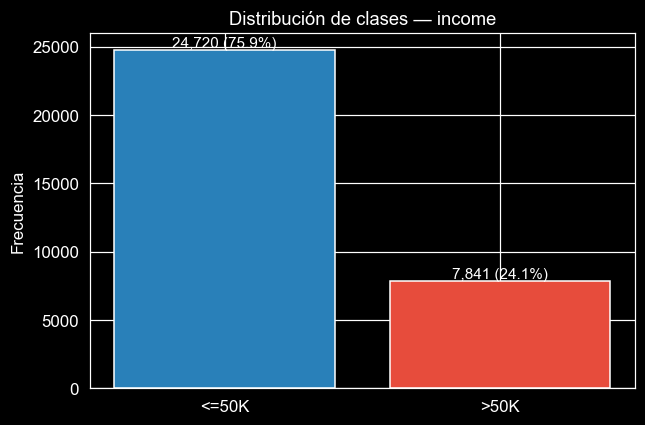

In [17]:
vc = adult_df['income'].value_counts()
print(vc)
print(f'\nProporción: {vc.values[0]/len(adult_df)*100:.1f}% vs {vc.values[1]/len(adult_df)*100:.1f}%')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(vc.index, vc.values, color=['#2980b9', '#e74c3c'], edgecolor='white')
ax.set_title('Distribución de clases — income'); ax.set_ylabel('Frecuencia')
for i, (k, v) in enumerate(vc.items()):
    ax.text(i, v + 200, f'{v:,} ({v/len(adult_df)*100:.1f}%)', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

### 2.3 Valores Implícitamente Nulos (\'?\')

In [18]:
print('Columnas con "?" seran tratados como NaN implícitos')
for col in adult_df.select_dtypes('object').columns:
    n = (adult_df[col].str.strip() == '?').sum()
    if n > 0:
        print(f'  {col:<20}: {n:>5} ({n/len(adult_df)*100:.1f}%)')

Columnas con "?" (tratados como NaN implícitos):
  workclass           :  1836 (5.6%)
  occupation          :  1843 (5.7%)
  native.country      :   583 (1.8%)


### 2.4 Distribuciones Numéricas por Clase

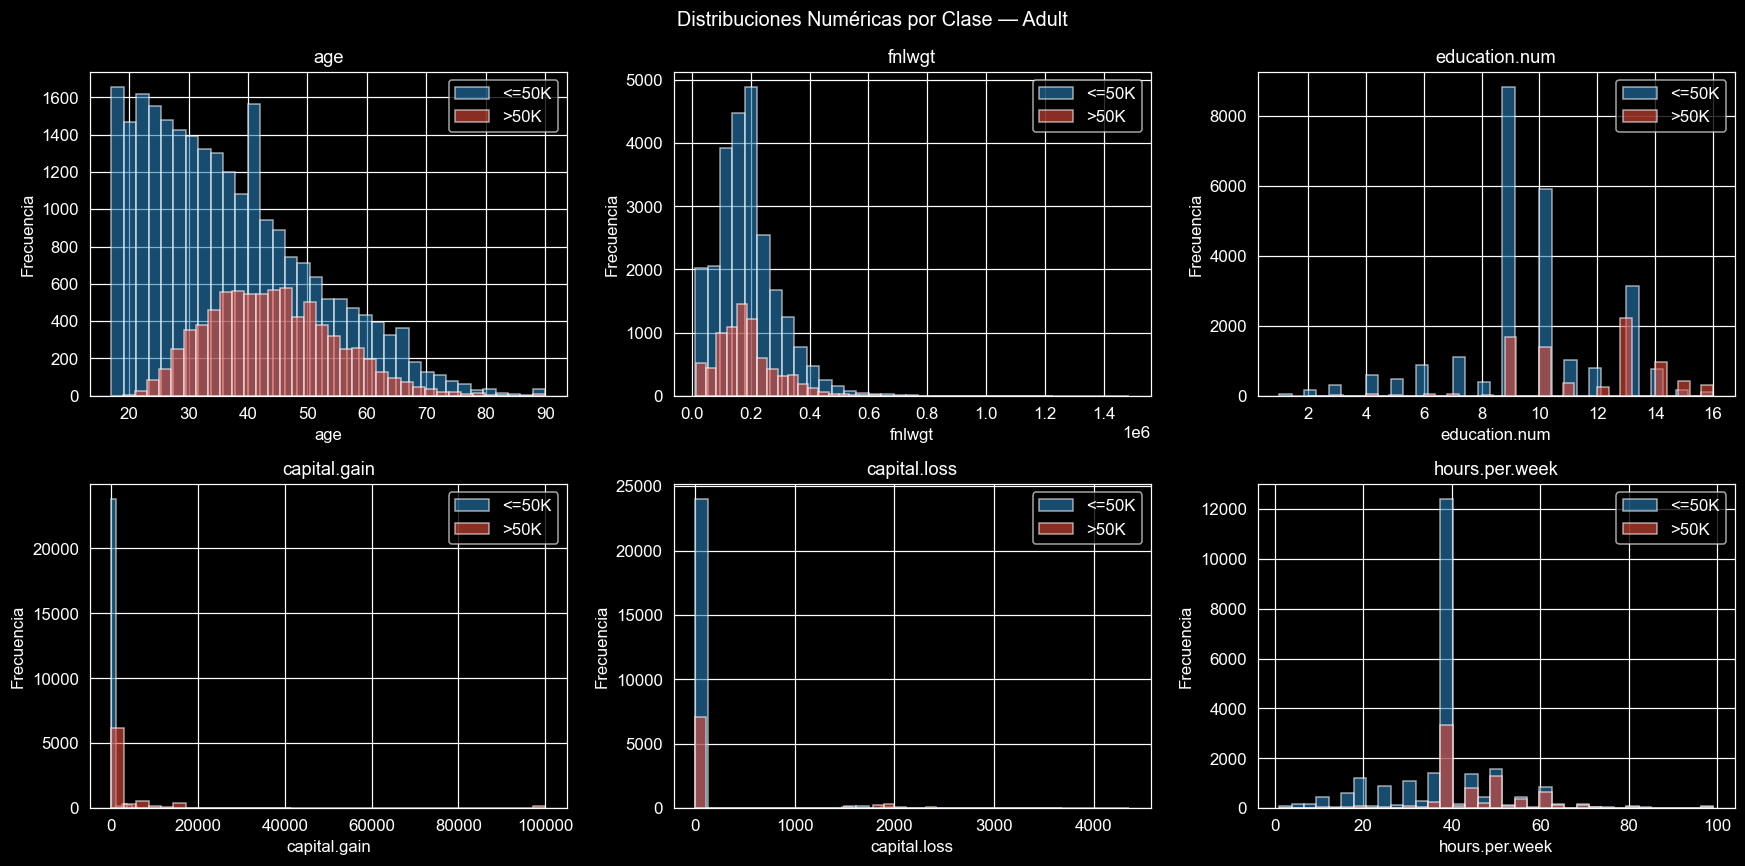

In [19]:
num_cols_a = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols_a):
    for cls, color in [('<=50K', '#2980b9'), ('>50K', '#e74c3c')]:
        axes[i].hist(adult_df[adult_df['income'] == cls][col],
                     bins=35, alpha=0.6, color=color, label=cls, edgecolor='white')
    axes[i].set_title(col); axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia'); axes[i].legend()
plt.suptitle('Distribuciones Numéricas por Clase — Adult', fontsize=13)
plt.tight_layout(); plt.show()

### 2.5 Variables Categóricas

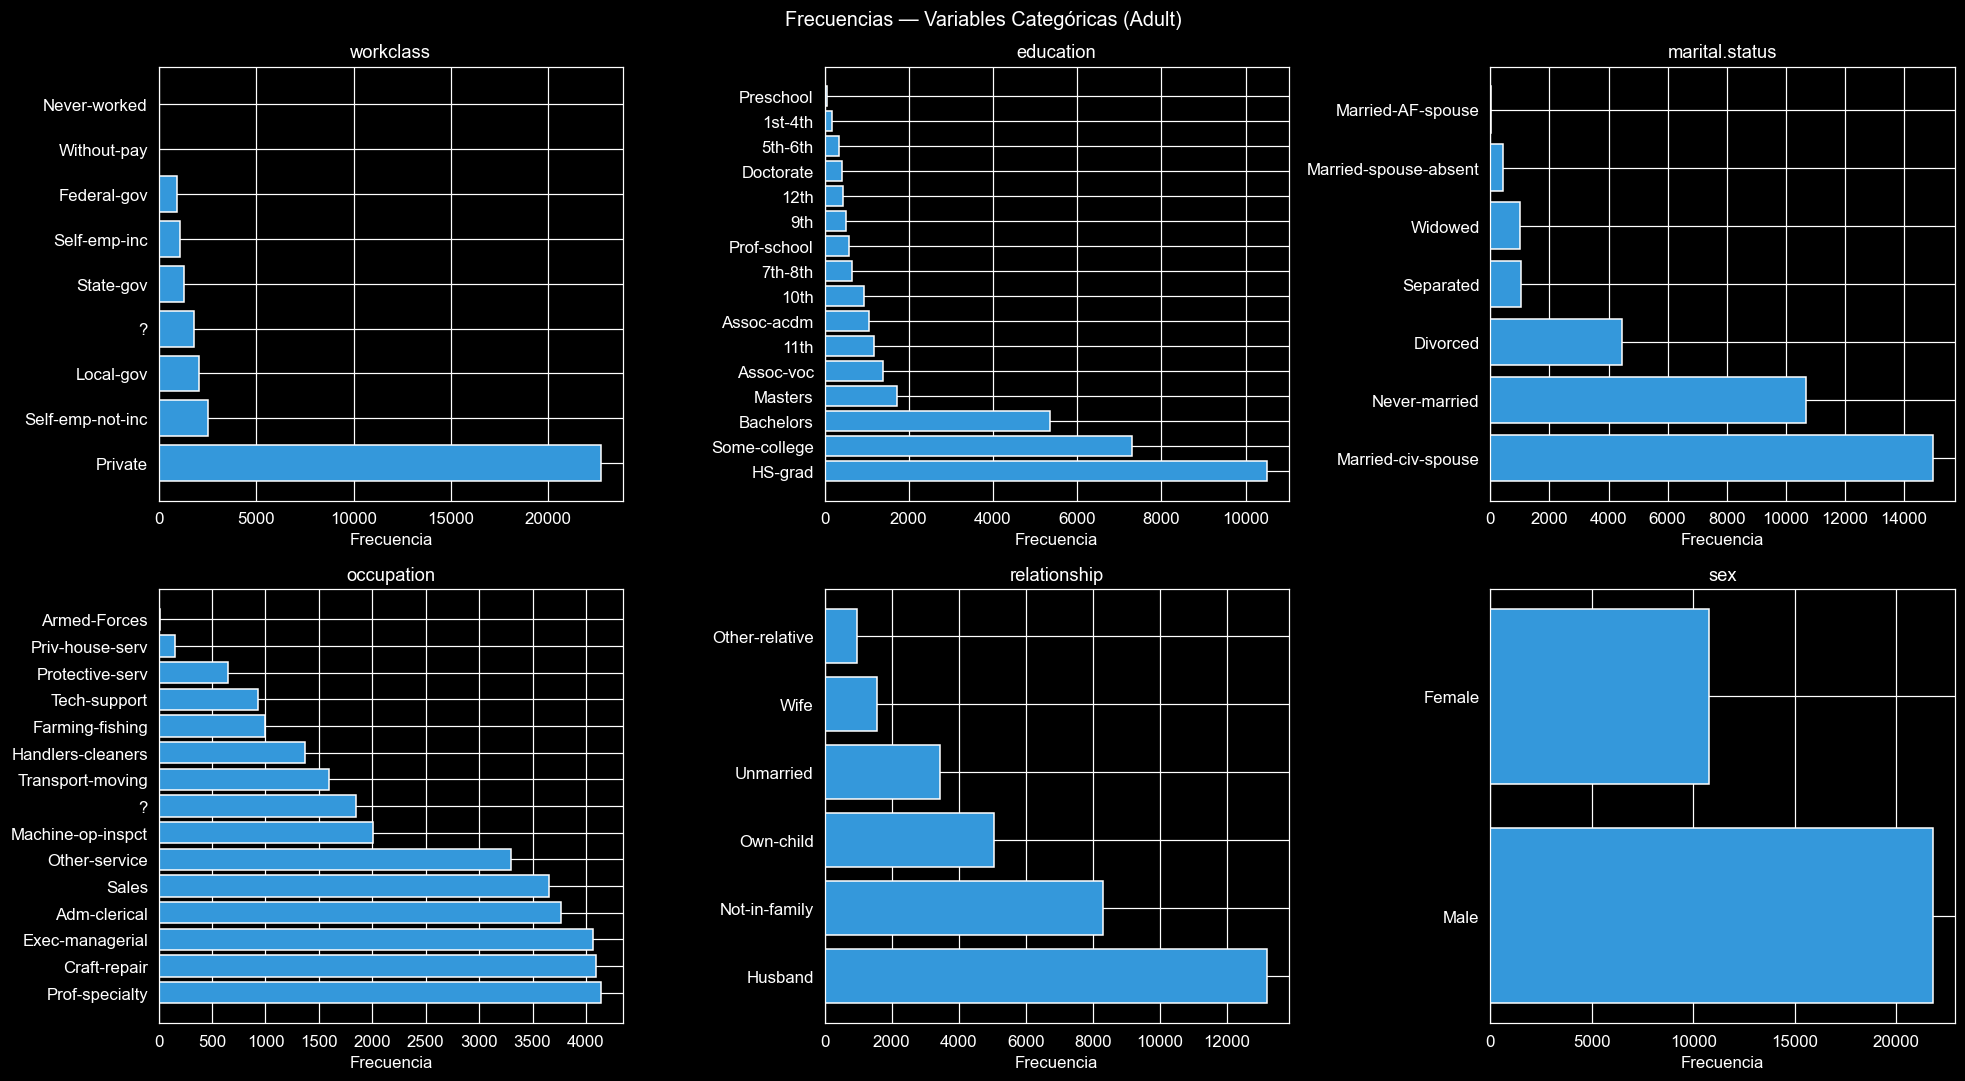

In [20]:
cat_cols_a = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'sex']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols_a):
    vc_col = adult_df[col].str.strip().value_counts()
    axes[i].barh(vc_col.index, vc_col.values, color='#3498db', edgecolor='white')
    axes[i].set_title(col); axes[i].set_xlabel('Frecuencia')
plt.suptitle('Frecuencias — Variables Categóricas (Adult)', fontsize=13)
plt.tight_layout(); plt.show()

### 2.6 Mapa de Correlaciones Numéricas

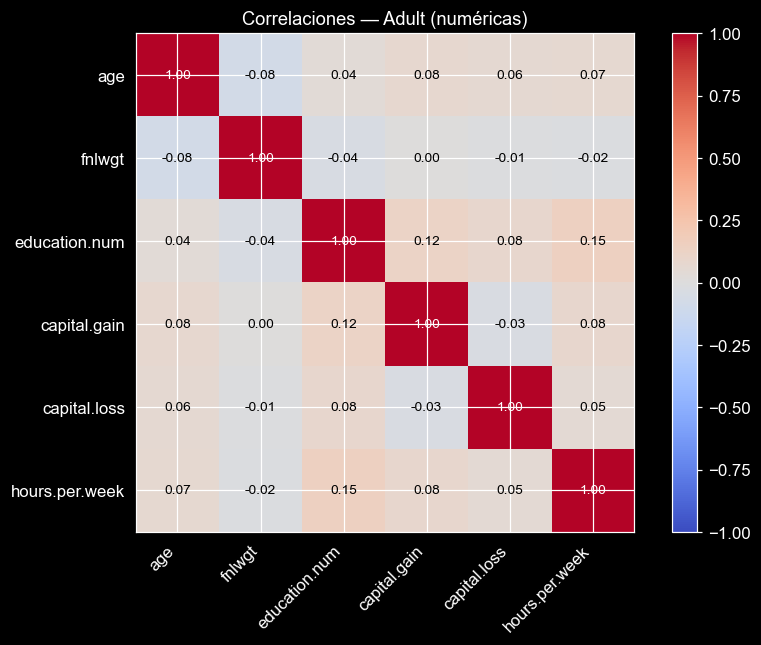

In [21]:
corr_a = adult_df[num_cols_a].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_a, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_a))); ax.set_xticklabels(corr_a.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr_a))); ax.set_yticklabels(corr_a.columns)
for i in range(len(corr_a)):
    for j in range(len(corr_a)):
        ax.text(j, i, f'{corr_a.iloc[i,j]:.2f}', ha='center', va='center',
                fontsize=9, color='white' if abs(corr_a.iloc[i,j]) > 0.5 else 'black')
plt.colorbar(im, ax=ax)
ax.set_title('Correlaciones — Adult (numéricas)')
plt.tight_layout(); plt.show()

## 3. Preprocesamiento Adult Census Income

| Decisión | Justificación |
|---|---|
| Reemplazar '?' por moda de la columna | Evita perder 2K+ filas; moda preserva la distribución |
| Eliminar `fnlwgt` | Peso muestral censal, no informativo para predicción individual |
| Eliminar `education` (texto) | Redundante con `education.num` (ya numérica y ordinal) |
| One-Hot Encoding de categóricas | Variables nominales sin orden; OHE evita ordinalidad artificial |
| Estandarización (StandardScaler) | GD requiere features en escala comparable |
| División 60/20/20 estratificada | Mantiene proporción de clases en cada split |
| One-Hot del target | Requerido por Softmax + CCE con dos clases |

In [22]:
df_a = adult_df.copy()

# 1. Limpiar espacios
for col in df_a.select_dtypes('object').columns:
    df_a[col] = df_a[col].str.strip()

# 2. Reemplazar '?' con moda
for col in df_a.select_dtypes('object').columns:
    mode_val = df_a[df_a[col] != '?'][col].mode()[0]
    df_a[col] = df_a[col].replace('?', mode_val)

# 3. Eliminar columnas redundantes
df_a = df_a.drop(columns=['fnlwgt', 'education'])

# 4. Separar target y codificar
y_a_raw = (df_a['income'] == '>50K').astype(int).values
df_a    = df_a.drop(columns=['income'])

# 5. One-Hot Encoding
df_a = pd.get_dummies(df_a, drop_first=False)
feature_names_a = df_a.columns.tolist()
X_a = df_a.values.astype(float)
print(f'Features post-OHE: {X_a.shape[1]}')

# 6. One-Hot del target
Y_a = np.eye(2)[y_a_raw]

# 7. División 60/20/20 estratificada
X_a_tmp, X_a_test, Y_a_tmp, Y_a_test, y_a_tmp, y_a_test = train_test_split(
    X_a, Y_a, y_a_raw, test_size=0.20, random_state=42, stratify=y_a_raw)
X_a_train, X_a_val, Y_a_train, Y_a_val, y_a_train, y_a_val = train_test_split(
    X_a_tmp, Y_a_tmp, y_a_tmp, test_size=0.25, random_state=42, stratify=y_a_tmp)

# 8. Estandarización fit SOLO en train
scaler_a = StandardScaler()
X_a_train_s = scaler_a.fit_transform(X_a_train)
X_a_val_s   = scaler_a.transform(X_a_val)
X_a_test_s  = scaler_a.transform(X_a_test)

print(f'Train: {X_a_train_s.shape} | Val: {X_a_val_s.shape} | Test: {X_a_test_s.shape}')

Features post-OHE: 88
Train: (19536, 88) | Val: (6512, 88) | Test: (6513, 88)


## 4. Implementación Regresión Logística con Softmax + CCE (NumPy)

**Softmax:** $\hat{P}(y=k|\mathbf{x}) = \frac{e^{z_k}}{\sum_j e^{z_j}}, \quad Z = XW + b$

**CCE Loss:** $J(W) = -\frac{1}{n}\sum_{i=1}^n \sum_{k} y_{ik}\log(\hat{p}_{ik})$

**Gradiente (Softmax + CCE combinados):** $\nabla_W J = \frac{1}{n} X^\top (\hat{P} - Y)$

In [23]:
class LogisticRegressionSoftmax:
    """
    Regresión Logística con Softmax con Categorical Cross-Entropy.
    Implementada en NumPym la usaremois para clasificación binaria y multiclase.
    Inicialización Xavier para estabilidad del gradiente.
    """

    def __init__(self, lr=0.01, epochs=500, seed=42):
        self.lr     = lr
        self.epochs = epochs
        self.seed   = seed
        self.W = self.b = None
        self.train_loss_history = []
        self.val_loss_history   = []

    @staticmethod
    def _softmax(Z):
        exp_Z = np.exp(Z - Z.max(axis=1, keepdims=True))
        return exp_Z / exp_Z.sum(axis=1, keepdims=True)

    def _cce(self, Y_hot, P_hat):
        return -np.mean(np.sum(Y_hot * np.log(P_hat + 1e-8), axis=1))

    def _forward(self, X):
        return self._softmax(X @ self.W + self.b)

    def fit(self, X_train, Y_train, X_val=None, Y_val=None, val_freq=50):
        np.random.seed(self.seed)
        n_feat, n_cls = X_train.shape[1], Y_train.shape[1]
        # Inicialización Xavier
        self.W = np.random.randn(n_feat, n_cls) * np.sqrt(1.0 / n_feat)
        self.b = np.zeros(n_cls)

        for epoch in range(self.epochs):
            P_hat = self._forward(X_train)
            loss  = self._cce(Y_train, P_hat)
            self.train_loss_history.append(loss)

            # Gradiente Softmax + CCE combinado
            delta  = P_hat - Y_train
            grad_W = X_train.T @ delta / X_train.shape[0]
            grad_b = delta.mean(axis=0)
            self.W -= self.lr * grad_W
            self.b -= self.lr * grad_b

            if X_val is not None and epoch % val_freq == 0:
                val_loss = self._cce(Y_val, self._forward(X_val))
                self.val_loss_history.append(val_loss)
                if epoch % 100 == 0:
                    print(f'Epoch {epoch:<5} | Train CCE: {loss:.4f} | Val CCE: {val_loss:.4f}')
        return self

    def predict_proba(self, X):
        return self._forward(X)

    def predict(self, X):
        return np.argmax(self._forward(X), axis=1)

In [24]:
model_log = LogisticRegressionSoftmax(lr=0.1, epochs=500, seed=42)
model_log.fit(X_a_train_s, Y_a_train, X_a_val_s, Y_a_val, val_freq=50)

Epoch 0     | Train CCE: 0.7988 | Val CCE: 0.7299
Epoch 100   | Train CCE: 0.3369 | Val CCE: 0.3496
Epoch 200   | Train CCE: 0.3248 | Val CCE: 0.3388
Epoch 300   | Train CCE: 0.3207 | Val CCE: 0.3355
Epoch 400   | Train CCE: 0.3186 | Val CCE: 0.3340


### 4.1 Curva de Pérdida Regresión Logística

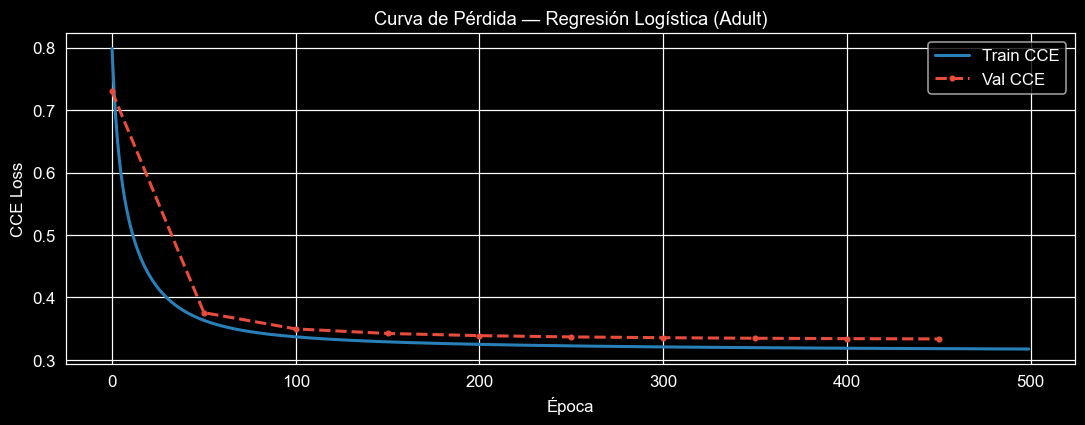

In [25]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(model_log.train_loss_history, label='Train CCE', color='#2980b9', lw=2)
ax.plot(np.arange(0, model_log.epochs, 50), model_log.val_loss_history,
        label='Val CCE', color='#e74c3c', lw=2, linestyle='--', marker='o', markersize=3)
ax.set_xlabel('Época'); ax.set_ylabel('CCE Loss')
ax.set_title('Curva de Pérdida — Regresión Logística (Adult)')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Evaluación Adult Census Income

EVALUACIÓN — Regresión Logística (Adult)
Métrica                   Train       Test
------------------------------------------
Accuracy                 0.8531     0.8515
F1-Score (macro)         0.7859     0.7841


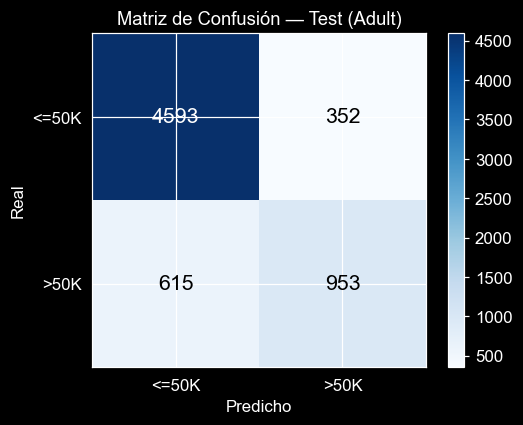

In [26]:
y_pred_train_a = model_log.predict(X_a_train_s)
y_pred_test_a  = model_log.predict(X_a_test_s)

acc_tr = accuracy_score(y_a_train, y_pred_train_a)
acc_te = accuracy_score(y_a_test,  y_pred_test_a)
f1_tr  = f1_score(y_a_train, y_pred_train_a, average='macro')
f1_te  = f1_score(y_a_test,  y_pred_test_a,  average='macro')

print('=' * 50)
print('EVALUACIÓN — Regresión Logística (Adult)')
print('=' * 50)
print(f"{'Métrica':<20} {'Train':>10} {'Test':>10}")
print('-' * 42)
print(f"{'Accuracy':<20} {acc_tr:>10.4f} {acc_te:>10.4f}")
print(f"{'F1-Score (macro)':<20} {f1_tr:>10.4f} {f1_te:>10.4f}")

cm = confusion_matrix(y_a_test, y_pred_test_a)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_xticklabels(['<=50K', '>50K'])
ax.set_yticks([0,1]); ax.set_yticklabels(['<=50K', '>50K'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=14,
                color='white' if cm[i,j] > cm.max()/2 else 'black')
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión — Test (Adult)')
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

### 5.1 Interpretación de Coeficientes Adult

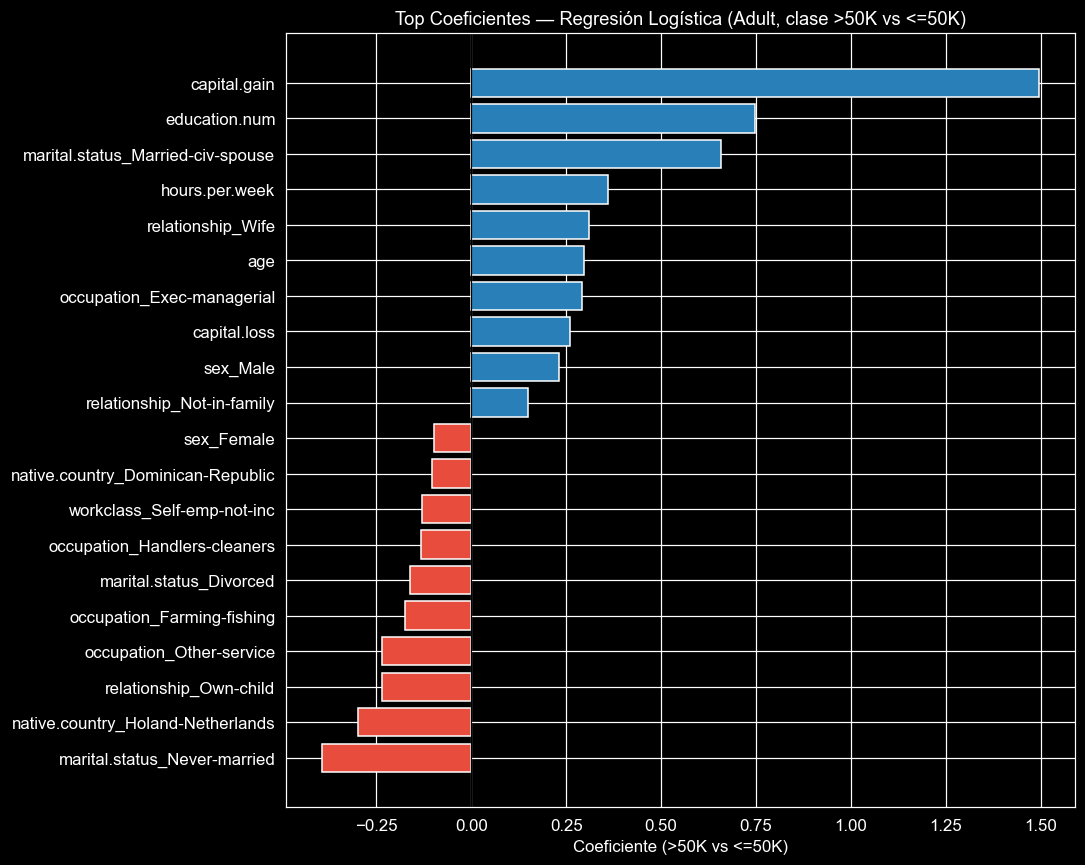

Top 10 features que aumentan P(>50K):


,feature,coeficiente
2,capital.gain,1.495053
1,education.num,0.748613
15,marital.status_Married-civ-spouse,0.657320
4,hours.per.week,0.359459
39,relationship_Wife,0.310746
0,age,0.297029
23,occupation_Exec-managerial,0.292427
3,capital.loss,0.258921
46,sex_Male,0.231783
35,relationship_Not-in-family,0.148445



Top 10 features que reducen P(>50K):


,feature,coeficiente
45,sex_Female,-0.098964
52,native.country_Dominican-Republic,-0.102543
10,workclass_Self-emp-not-inc,-0.129157
25,occupation_Handlers-cleaners,-0.132821
13,marital.status_Divorced,-0.160880
24,occupation_Farming-fishing,-0.174775
27,occupation_Other-service,-0.234241
37,relationship_Own-child,-0.235562
61,native.country_Holand-Netherlands,-0.298976
17,marital.status_Never-married,-0.393063


In [27]:
# Diferencia de coeficientes clase >50K vs clase <=50K
coef_diff = model_log.W[:, 1] - model_log.W[:, 0]
coef_df_a = pd.DataFrame({'feature': feature_names_a, 'coeficiente': coef_diff})\
             .sort_values('coeficiente', ascending=False)

top = pd.concat([coef_df_a.head(10), coef_df_a.tail(10)]).sort_values('coeficiente')
colores = ['#e74c3c' if c < 0 else '#2980b9' for c in top['coeficiente']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top['feature'], top['coeficiente'], color=colores, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Top Coeficientes — Regresión Logística (Adult, clase >50K vs <=50K)')
ax.set_xlabel('Coeficiente (>50K vs <=50K)')
plt.tight_layout(); plt.show()

print('Top 10 features que aumentan P(>50K):')
display(coef_df_a.head(10))
print('\nTop 10 features que reducen P(>50K):')
display(coef_df_a.tail(10))

**Interpretación:**

- `education.num` coeficiente positivo más alto: mayor educación → mayor probabilidad de superar $50K, consistente con la distribución del EDA donde >50K concentra más años de educación.
- `capital.gain` positivo: ingresos de capital son indicador directo de riqueza.
- `relationship_Wife` y `marital.status_Married-civ-spouse` positivos: el estado civil casado correlaciona con ingresos mayores, posiblemente por estabilidad laboral.
- `relationship_Own-child` negativo: hijos en el hogar correlacionan con ingresos bajos (individuos jóvenes dependientes).
- `sex_Male` positivo: refleja la brecha salarial de género documentada en el censo de 1994.